In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] ='Malgun Gothic'
#plt.rcParams['font.family'] = 'AppleGothic' # 맥
plt.rcParams['axes.unicode_minus'] =False

선형 회귀 - 닫힌 형태의 방정식, 경사 하강법

# 선형 회귀

선형 회귀 모델의 예측 : $ \widehat{y} = \theta_0 + \theta_1x_1 + \theta_2x_2 + ... + \theta_nx_n $

$ \widehat{y} $ : 예측 값

$ n $ : 특성의 수

$ x_i $ : i번째 특성 값

$ \theta_j $ : j번째 모델 파라미터

<br>

선형 회귀 모델의 예측(백터 형태) : $ \widehat{y} = h_\theta(x) = \theta \bullet x $

$ h_0 $ : 모델 파라미터 $ \theta $를 사용한 가설 함수

$ \theta $ : 편향 $ \theta_0 $과 $ \theta_1 $까지의 특성 가중치를 담음 모델의 파라미터 벡터

$ x $ : $ x_0 $에서 $ x_n $까지 담은 샘플의 특성 백터

$ \theta \bullet x $ : 벡터 $ \theta $와 x의 점곱 => $ \theta_0x_0 + \theta_1x_1 + \theta_2x_2 + ... + \theta_nx_n $과 같다

<br>

=> 회귀에서 가장 널리 사용되는 성능 축정 지표는 평균 제곱근 오차(RMSE)

=> 선형 회귀 모델을 훈련시키려면 RMSE를 최소화하는 $ \theta $를 찾아야 한다

<br>

훈련 세트 $ X $에 대한 선형 회귀 가설 $ h_\theta $의 MSE는

$ MSE(X, h_\theta) = {1 \over m}\sum_{i = 1}^m (\theta ^ T x ^ {(i)} - y ^ {(i)}) ^ 2 $

## 정규 방정식

 정규 방정식 : $ \widehat{\theta} = (X^TX)^{-1} X^Ty $

### 직접 입력

array([[0.74908024],
       [1.90142861],
       [1.46398788],
       [1.19731697],
       [0.31203728]])

array([[6.33428778],
       [9.40527849],
       [8.48372443],
       [5.60438199],
       [4.71643995]])

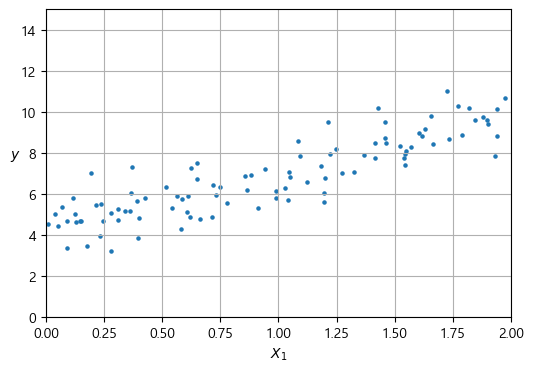

In [2]:
np.random.seed(42)  # 동일하게 재현 가능하게 만들기 위해
m = 100  # 샘플 개수
X = 2 * np.random.rand(m, 1)  # 열 벡터
y = 4 + 3 * X + np.random.randn(m, 1)  # 열 벡터

X[:5]
y[:5]


_=plt.figure(figsize = (6, 4))
_=plt.scatter(X, y, s = 5)
_=plt.xlabel('$ X_1 $')
_=plt.ylabel('$ y $', rotation = 0)
_=plt.grid()
_=plt.axis([0, 2, 0, 15])

정규 방정식을 사용해 $ \widehat{\theta} \quad$($ \widehat{\theta} = (X^TX)^{-1} X^Ty $)을 계산

inv() 함수를 사용해 역행렬을 계산하고 dot()을 사용해 행렬 곱셈

In [3]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X) # 각 샘플에 x0 = 1을 추가
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

In [4]:
theta_best

array([[4.21509616],
       [2.77011339]])

$ \widehat{\theta} $을 사용해 예측

$ y = \theta_0 + \theta_1x \quad => y = b + ax $

$\theta_0(절편 = 편향) = 4.215, \quad \theta_1(기울기 = 가중치) = 2.770$

$ x = 0 \quad y = 4.21509616$

$ x = 1  \quad y = 9.75532293$

array([[1., 0.],
       [1., 2.]])

array([[4.21509616],
       [9.75532293]])

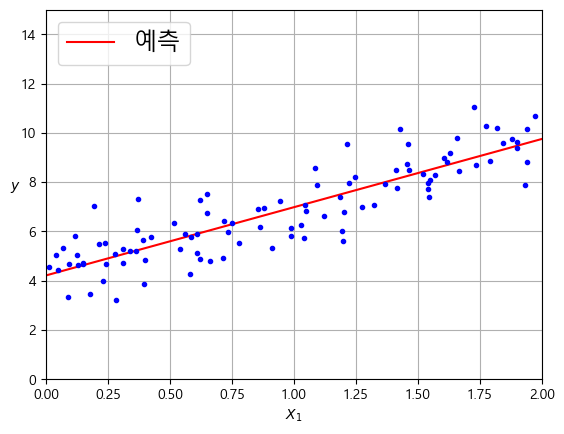

In [5]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)

X_new_b[:5]

y_predict = X_new_b @ theta_best 
y_predict

_=plt.plot(X_new, y_predict, 'r-', label = '예측')
_=plt.plot(X, y, 'b.')
_=plt.xlabel('$ X_1 $')
_=plt.ylabel('$ y $', rotation = 0)
_=plt.grid()
_=plt.axis([0, 2, 0, 15])
_=plt.legend(loc = 'upper left', fontsize = 17)

### 사이킷런 이용

In [6]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)

lin_reg.intercept_, lin_reg.coef_ # intercept = 편향(theta0), coef = 가중치(theta1)
lin_reg.predict(X_new)

LinearRegression()

(array([4.21509616]), array([[2.77011339]]))

array([[4.21509616],
       [9.75532293]])

In [7]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond = 1e-6) # 최소 제곱

theta_best_svd # 최적의 파라미터를 보기 위해(theta)

array([[4.21509616],
       [2.77011339]])

# 경사 하강법

여러 종류의 문제에서 최적의 해법을 찾을 수 있는 일반적인 최적화 알고리즘

비용 함수를 최소화하기 위해 반복해서 파라미터를 조정(파라미터 벡터 $\theta$에 대해 비용 함수의 현재 그레이디언트(기울기)를 계산)

그레이디언트가 감소하는 방향으로 진행 => 그레이디언트가 0이 되면 최솟값에 도달

=> $\theta$를 임의의 값으로 시작해서(랜덤 초기화) 한 번에 조금씩 비용 함수(MSE)가 감소되는 방향으로 최솟값에 수렴할 때까지

$\color{Red}*중요한 파라미터는 스텝(단계)의 크기로, 학습률 하이퍼파라미터로 결정\color{Red}*$

$\color{Red}*모든 특성의 스케일을 같게 만들어야 한다\color{Red}*$


<br>

경사 하강법의 문제점

- 일찍 멈춰 전역 최솟값에 도달하지 못 한다
- 왼쪽에서 시작하면 전역 최솟값보다 덜 졸은 지역 최솟값에 도달한다

## 배치 경사 하강법

- 각 모델 파리미터 $\theta_j$에 대해 비용 함수의 그레이디언트를 계산 => 편도 함수

- 비용 함수의 편도함수

${\partial\over\partial\theta_j} MSE(\theta) = {2\over m}\sum_{i = 1}^m (\theta ^ T x ^ {(i)} - y ^ {(i)})x_j^{(i)} $

<br>

- 비용 함수의 그레이디언트 벡터

$\nabla_\eta MSE(\theta) = \begin{pmatrix} {\partial\over\partial\theta_0} MSE(\theta) \\ {\partial\over\partial\theta_1} MSE(\theta) \\ ... \\{\partial\over\partial\theta_n} MSE(\theta) \end{pmatrix} = {2\over m}X ^ T(X\theta - y) $

<br>

- 경사 하강법의 스텝($\eta$ = 학습률)

$\theta^{(next step)}= \theta - \nabla_\eta\theta MSE(\theta)$

In [9]:
eta = 0.1 # 학습률
n_epochs = 1000
m = len(X_b) # 샘플 개수

np.random.seed(42)
theta = np.random.randn(2, 1) # 모델 파리미터를 랜덤으로 초기화

for epoch in range(n_epochs):
    gradients = 2 / m * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients

In [11]:
theta

array([[4.21509616],
       [2.77011339]])

반복 횟수를 아주 크게 지정하고 그레이디언트 벡터가 아주 작아지면 => 벡터의 노름이 어떤 값(허용오차)보다 작아지면 경사 하강법이 최솟값에 도달

## 확률적 경사 하강법

- 매 스텝에서 한 개의 샘플을 랜덤으로 선택하고 그 하나의 샘플에 대한 그레이디언트를 계산

- 매 반복에서 학습률을 결정하는 함수 : 학습 스케줄

In [13]:
# 간단한 학습 스케줄을 사용한 경사 하강법

n_epochs = 50
t0, t1 = 5, 50 # 학습 스케줄 파라미터

def learning_schedule(t):
    return t0 / (t + t1)

np.random.seed(42)
theta = np.random.randn(2, 1) # 랜덤 초기화

for epoch in range(n_epochs):
    for iteration in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index + 1]
        yi = y[random_index:random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi) # SGD의 경우 m으로 나누지 않는다
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients

In [14]:
theta

array([[4.21076011],
       [2.74856079]])

In [15]:
# 최대 1000번 에포크동안 실행

from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter = 1000, tol = 1e-5, penalty = None, eta0 = 0.01,
                      n_iter_no_change = 100, random_state = 42)
sgd_reg.fit(X, y.ravel()) # fit()이 1D 타깃을 기대하기 때문에 y.ravel()로 사용

SGDRegressor(n_iter_no_change=100, penalty=None, random_state=42, tol=1e-05)

In [17]:
sgd_reg.intercept_, sgd_reg.coef_

(array([4.21278812]), array([2.77270267]))

## 미니배치 경사 하강법

# 다항 회귀

- 각 특성의 거듭제곱을 새로운 특성으로 추가하고, 이 확장된 특성을 포함한 데이터셋에 선형 모델을 훈련

In [18]:
# 2차 방정식에 약간의 잡음을 추가한 비선형 데이터 생성

np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)

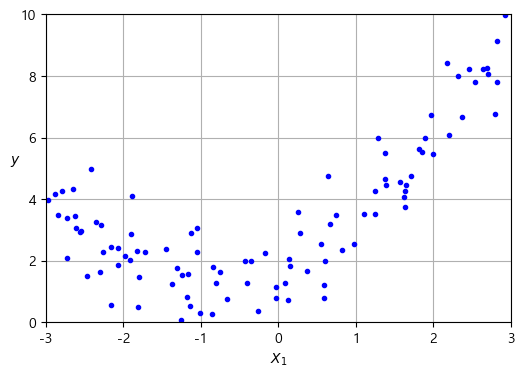

In [22]:
plt.figure(figsize=(6, 4));
plt.plot(X, y, "b.");
plt.xlabel("$ X_1$");
plt.ylabel("$y$", rotation=0);
plt.axis([-3, 3, 0, 10]);
plt.grid();

In [19]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree = 2, include_bias = False)
X_ploy = poly_features.fit_transform(X)

X[0]
X_ploy[0]

array([-0.75275929])

array([-0.75275929,  0.56664654])

In [20]:
lin_reg = LinearRegression()
lin_reg.fit(X_ploy, y) # X_ploy는 이제 원래 특성의 X와 이 특성의 제곱을 포함
lin_reg.intercept_, lin_reg.coef_

LinearRegression()

(array([1.78134581]), array([[0.93366893, 0.56456263]]))

원래 함수 : $ y = 0.5X ^ 2 + X + 2 $ 

->

예측된 모델 : $\widehat y = 0.56X^2 + 0.93X + 1.78$

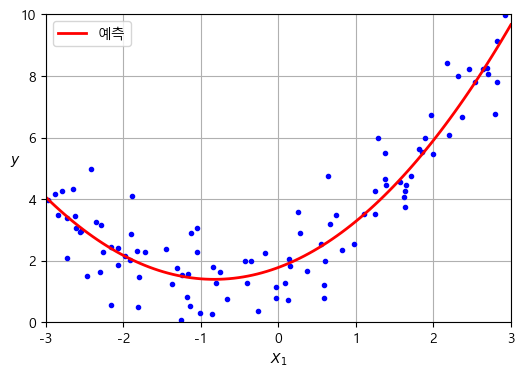

In [23]:
X_new = np.linspace(-3, 3, 100).reshape(100, 1) # np.linspace(start, end, num) : 1차원 배열 만들기
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)


plt.figure(figsize=(6, 4));
plt.plot(X, y, "b.");
plt.plot(X_new, y_new, "r-", linewidth=2, label="예측")
plt.xlabel("$ X_1$");
plt.ylabel("$y$", rotation=0);
plt.axis([-3, 3, 0, 10]);
plt.legend(loc="upper left");
plt.grid();

# 학습 곡선

<모델의 일반화 성능 추정>

방법 1. 교차 검증을 진행

-> 훈련 데이터에서 성능이 좋지만 교차 검증 점수가 나쁘다면 모델이 과대적합

-> 만약 양쪽에 모두 좋지 않으면 과소적합

<br>

방법 2. 학습 곡선 확인

- 학습 곡선 : 모델의 훈련 오차와 검증 오차를 훈련 반복 횟수의 함수로 나타낸 그래프

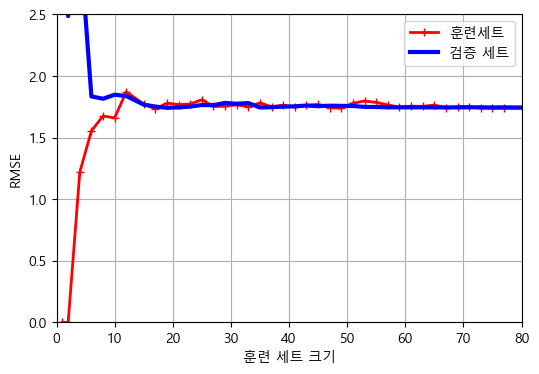

In [34]:
# 선형 회귀 모델의 학습 곡선

from sklearn.model_selection import learning_curve # 교차 검증을 사용하여 모델을 훈련하고 평가하는 함수

train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(), X, y, train_sizes = np.linspace(0.01, 1.0, 40), cv = 5,
    scoring = 'neg_root_mean_squared_error')

train_errors = -train_scores.mean(axis = 1)
valid_errors = -valid_scores.mean(axis = 1)

plt.figure(figsize=(6, 4));
plt.plot(train_sizes, train_errors, 'r-+', linewidth = 2, label = '훈련세트');
plt.plot(train_sizes,valid_errors, 'b-', linewidth = 3, label = '검증 세트');
plt.legend(loc = 'upper right');
plt.grid();
plt.xlabel('훈련 세트 크기');
plt.ylabel('RMSE');
plt.axis([0, 80, 0, 2.5]);

위 모델은 과소적합이다

훈련 세트에 샘플이 추가됨에 따라 잡음도 있고 비선형이기 때문에 모델이 훈련 데이터를 완벽히 학습하는 것이 불가능 

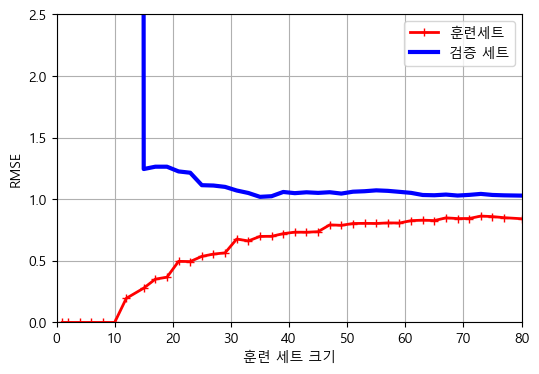

In [37]:
# 같은 데이터에서 10차 다항 회귀 모델의 학습 곡선 그리기

from sklearn.pipeline import make_pipeline

polynomial_regression = make_pipeline(
    PolynomialFeatures(degree = 10, include_bias = False),
    LinearRegression())

train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression, X, y, train_sizes = np.linspace(0.01, 1.0, 40), cv = 5,
    scoring = 'neg_root_mean_squared_error')


train_errors = -train_scores.mean(axis = 1)
valid_errors = -valid_scores.mean(axis = 1)

plt.figure(figsize=(6, 4));
plt.plot(train_sizes, train_errors, 'r-+', linewidth = 2, label = '훈련세트');
plt.plot(train_sizes, valid_errors, 'b-', linewidth = 3, label = '검증 세트');
plt.legend(loc = 'upper right');
plt.grid();
plt.xlabel('훈련 세트 크기');
plt.ylabel('RMSE');
plt.axis([0, 80, 0, 2.5]);

두 곡선 사이의 공간 : 검증 데이터에서보다 훈련 데이터에서 모델이 훨씬 더 나은 성능을 보인다 -> 과대적합

# 규제가 있는 선형 모델

## 릿지 회귀

- 규제가 추가된 선형 회귀 버전

- 릿지회귀의 비용 함수

$J(\theta) = MSE(\theta) + {\alpha\over m}\sum_{i = 1}^n \theta_i ^ 2$

<br>

- 릿지 회귀의 정규 방정식

$\widehat\theta = (X^TX + \alpha A)^{-1}X^Ty$

In [44]:
np.random.seed(42)
m = 20
X = 3 * np.random.rand(m, 1)
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)

In [45]:
# 정규 방정식을 사용한 릿지 회귀를 적용

from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha = 0.1, solver = 'cholesky')
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

Ridge(alpha=0.1, solver='cholesky')

array([[1.55325833]])

In [46]:
# 확률적 경사 하강법 사용

sgd_reg = SGDRegressor(penalty = 'l2', alpha = 0.1 / m, tol = None,
                       max_iter = 1000, eta0 = 0.01, random_state = 42)

sgd_reg.fit(X, y.ravel())
sgd_reg.predict([[1.5]])

SGDRegressor(alpha=0.005, random_state=42, tol=None)

array([1.55302613])

## 라쏘 회귀

- 릿지 회귀처럼 비용 함수에 규제항을 더하지만, 노름 대신 가중치 벡터의 노름을 이용

- 라쏘 회귀의 비용 함수

$J(\theta) = MSE(\theta) + 2\alpha\sum_{i = 1}^n|\theta_i|$

- 덜 중요한 특성의 가중치를 제거(=> 가중치가 0이다)

In [47]:
np.random.seed(42)
m = 20
X = 3 * np.random.rand(m, 1)
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)

In [51]:
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha = 0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

Lasso(alpha=0.1)

array([1.53788174])

In [52]:
# 확률적 경사 하강법 사용

sgd_reg = SGDRegressor(penalty = 'l1', alpha = 0.1, tol = None,
                       max_iter = 1000, eta0 = 0.01, random_state = 42)

sgd_reg.fit(X, y.ravel())
sgd_reg.predict([[1.5]])

SGDRegressor(alpha=0.1, penalty='l1', random_state=42, tol=None)

array([1.53728962])

## 엘라스틱넷

- 릿지 회귀와 라쏘 회귀를 절충한 모델

- 규제항 : 릿지와 회귀의 규제항을 단순히 더한 것

- 혼합정도 : 혼합 비율

- r = 0: : 릿지 회귀, r = 1 : 라쏘 회귀

<br>

- 엘라스틱넷 비용 함수

$J(\theta) = MSE(\theta) + r(2\alpha\sum_{i = 1}^n|\theta_i|) + (1 - r)({\alpha\over m}\sum_{i = 1}^n\theta_i^2)$

In [53]:
np.random.seed(42)
m = 20
X = 3 * np.random.rand(m, 1)
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)

In [57]:
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha = 0.1, l1_ratio = 0.5)
elastic_net.fit(X, y)
elastic_net.predict([[1.5]])

ElasticNet(alpha=0.1)

array([1.54333232])

## 조기 종료

- 검증 오차가 최소에 도달하는 즉시 훈련을 멈춘다

In [59]:
# 다항 특성을 추가, 훈련 세트와 검증 세트 모두에 대해 모든 입력 특성의 스케일 조정
# 규제가 없고 학습률이 작은 SGDRegressor 모델 생성
# 점진적인 학습 수행

from copy import deepcopy
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)
X_train, y_train = X[: m // 2], y[: m // 2, 0]
X_valid, y_valid = X[m // 2 :], y[m // 2 :, 0]


preprocessing = make_pipeline(PolynomialFeatures(degree = 90, include_bias = False),
                              StandardScaler())

X_train_prep = preprocessing.fit_transform(X_train)
X_val_prep = preprocessing.fit_transform(X_valid)
sgd_reg = SGDRegressor(penalty = None, eta0 = 0.002, random_state = 42)
n_epochs = 500
best_valid_rmse = float('inf')

for epoch in range(n_epochs):
    sgd_reg.partial_fit(X_train_prep, y_train) # 학습된 것을 유지하면서 반복 학습
    y_valid_predict = sgd_reg.predict(X_val_prep)
    val_error = mean_squared_error(y_valid, y_valid_predict, squared = False)
    
    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_model = deepcopy(sgd_reg)

SGDRegressor(eta0=0.002, penalty=None, random_state=42)

SGDRegressor(eta0=0.002, penalty=None, random_state=42)

SGDRegressor(eta0=0.002, penalty=None, random_state=42)

SGDRegressor(eta0=0.002, penalty=None, random_state=42)

SGDRegressor(eta0=0.002, penalty=None, random_state=42)

...

SGDRegressor(eta0=0.002, penalty=None, random_state=42)

SGDRegressor(eta0=0.002, penalty=None, random_state=42)

SGDRegressor(eta0=0.002, penalty=None, random_state=42)

SGDRegressor(eta0=0.002, penalty=None, random_state=42)

SGDRegressor(eta0=0.002, penalty=None, random_state=42)

# 로지스틱 회귀

## 확률 추정

- 입력 특성의 가중치 합을 계산 후 편향 더하기

- 로지스틱은 0과 1의 사이 값을 출력하는 시그모이드함수

- 로지스틱 함수 : $1\over {1 + exp(-t)}$

 - 로지스틱 회귀 모델 예측
     $\widehat y \begin{cases}
0, & \widehat p <0.5일때 \\
1, & \widehat p >=0.5일때
\end{cases}$

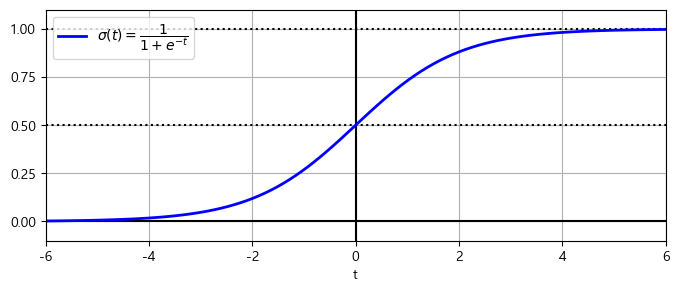

In [3]:
# 로지스틱 함수

lim = 6
t = np.linspace(-lim, lim, 100)
sig = 1 / (1 + np.exp(-t))

plt.figure(figsize=(8, 3));
plt.plot([-lim, lim], [0, 0], "k-");
plt.plot([-lim, lim], [0.5, 0.5], "k:");
plt.plot([-lim, lim], [1, 1], "k:");
plt.plot([0, 0], [-1.1, 1.1], "k-");
plt.plot(t, sig, "b-", linewidth=2, label=r"$\sigma(t) = \dfrac{1}{1 + e^{-t}}$");
plt.xlabel("t");
plt.legend(loc="upper left");
plt.axis([-lim, lim, -0.1, 1.1]);
plt.gca().set_yticks([0, 0.25, 0.5, 0.75, 1]);
plt.grid();

## 훈련과 비용 함수

## 결정 경계

꽃잎의 너비를 기반으로 Iris-Versicolor 종을 감지하는 분류기 만들기

In [4]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame = True)
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [5]:
iris.data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [7]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [37]:
from sklearn.model_selection import train_test_split

X = iris.data[["petal width (cm)"]].values
y = iris.target_names[iris.target] == 'virginica'
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [38]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(random_state=42)

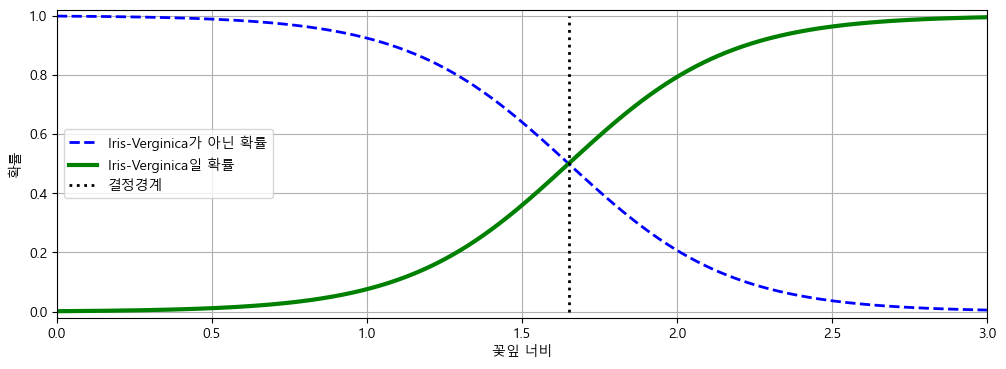

In [51]:
# 꽃잎의 너비가 0~3cm인 꽃에 대해 모델의 추정 확률 계산

X_new = np.linspace(0, 3, 1000).reshape(-1, 1)  # 크기를 바꾸어 열 벡터를 얻습니다.
y_proba = log_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]

plt.figure(figsize = (12, 4));
plt.plot(X_new, y_proba[:, 0], 'b--', linewidth = 2,
        label = 'Iris-Verginica가 아닌 확률');
plt.plot(X_new, y_proba[:, 1], 'g-', linewidth = 3, label = 'Iris-Verginica일 확률');
plt.plot([decision_boundary, decision_boundary], [0, 1], 'k:', linewidth = 2, label = '결정경계');
plt.grid();
plt.legend(loc = 'center left');
plt.axis([0, 3, -0.02, 1.02]);
plt.xlabel('꽃잎 너비');
plt.ylabel('확률');

=> 중간에는 Verginica라 완벽하게 말 할 수 없다

In [54]:
decision_boundary
log_reg.predict([[1.7], [1.5]])

1.6516516516516517

array([ True, False])

## 소프트맥스 회귀

- 다항 로지스틱 회귀

- 가장 높은 점수를 가진 클래스 선택(argmax)

- 한 번에 하나의 클래스만 예측

- 모델이 타깃 클래스에 대해서는 높은 확률, 다른 클래스에 대해서는 낮은 확률

- 비용 함수 : 크로스 엔트로피(추정된 클래스의 확률이 타깃 클래스에 얼마나 잘 맞는지 추정)

In [57]:
# 꽃잎의 길이가 5cm이고 너비가 2cm인 붓꽃을 발견했다고 가정하고 이 붓꽃의 품종이 뭔지 분류

X = iris.data[['petal length (cm)', 'petal width (cm)']].values
y = iris['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)

softmax_reg = LogisticRegression(C = 30, random_state = 42) # C를 사용하여 조절할 수 있는 l2 규제
softmax_reg.fit(X_train, y_train)

# 예측
softmax_reg.predict([[5, 2]]) #0(setosa), 1(versicolor), 2(virginica) 중 2라고 예측

# 확률 예측
softmax_reg.predict_proba([[5, 2]]).round(2)

LogisticRegression(C=30, random_state=42)

array([2])

array([[0.  , 0.04, 0.96]])